# ╔════════════════════════════════════════════════════════════╗
# ║ 🍄 きのこ　🍄
# ╚════════════════════════════════════════════════════════════╝


# ===================== IMPORTS ======================

In [62]:
# ═════════════════════ LOAD ═════════════════════
from pathlib import Path
import os

# ═════════════════════ SECTION ═════════════════════
import pandas as pd
import numpy as np

# ═════════════════════ VISUALIZATION TOOLS ═════════════════════
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# ═════════════════════ CNN ═════════════════════
from tensorflow.keras import Sequential, layers, optimizers, callbacks, regularizers, Model
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.metrics import AUC
import tensorflow as tf

# ═════════════════════ OTHER ═════════════════════
from datetime import datetime
from tensorflow.keras.preprocessing.image import load_img, save_img, img_to_array

# ===================== PREPROCESSING ======================

In [45]:
# # ░░░░░░░░░░░░░░ DATA AUGMENTATION (edible) ░░░░░░░░░░░░░░

# def augment_edible(edible_dir="data/image_dataset/edible"):
#     paths = list(Path(edible_dir).rglob("*.png"))

#     for p in paths:
#         save_img(str(p.parent / f"aug_{p.name}"), np.fliplr(img_to_array(load_img(p))))

# augment_edible()

# DO NOT RUN

In [63]:
print(f"🍄 Edible: {len(list(Path('../data/image_dataset/edible').rglob('*.jpg')) + list(Path('../data/image_dataset/edible').rglob('*.png')))}")
print(f"☠️ Poisonous: {len(list(Path('../data/image_dataset/poisonous').rglob('*.jpg')) + list(Path('../data/image_dataset/poisonous').rglob('*.png')))}")

🍄 Edible: 4950
☠️ Poisonous: 5497


# =====================[■■■■■■■■■□] 90% LOADING ======================


In [64]:
paths = list(Path("../data/image_dataset/").rglob("*.png"))
df = pd.DataFrame({
    "path": paths,
    "label": [p.parent.name for p in paths]
})

# ===================== CONFIGURATION ======================

In [65]:
# ░░ 💾 Save best model ░░
timestamp = datetime.now().strftime("%d%m%Y_%H%M%S")
os.makedirs("../models/images/baseline/keras_models", exist_ok=True)
MODEL_1 = "../models/images/baseline/keras_models/model_1.keras"
MODEL_2 = "../models/images/baseline/keras_models/augmented_1.keras"
MODEL_3 = "../models/images/baseline/keras_models/augmented_2.keras"


# ░░ 🏋 Training history logs ░░
os.makedirs("../models/images/baseline/logs", exist_ok=True)
csv_logger_1 = CSVLogger(f"../models/images/baseline/logs/baseline_history_{timestamp}.csv")
csv_logger_2 = CSVLogger(f"../models/images/baseline/logs/augmented_history_{timestamp}.csv")
csv_logger_3 = CSVLogger(f"../models/images/baseline/logs/augmented_2_history_{timestamp}.csv")

# ===================== MODEL BASELINE ======================

In [66]:
def initialize_baseline_model():
    baseline = Sequential([
        layers.Input(shape=(128, 128,3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, kernel_size = (4,4), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(512, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(1, activation="sigmoid")
    ])

    return baseline


In [67]:
baseline = initialize_baseline_model()
baseline.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_10 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 128, 128, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 16, 16, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,881,761 (18.62 MB)

 Trainable params: 4,880,289 (18.62 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [68]:
# ░░░░░░░░░░░░░░ Compilation ░░░░░░░░░░░░░░

def compile_baseline_model(baseline):
    adam = optimizers.Adam(learning_rate = 1e-4)
    baseline.compile(
        loss = "binary_crossentropy",
        optimizer=adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )

    return baseline

In [69]:
dataset_dir = os.path.abspath("../data/image_dataset")

# ░░░░░░░░░░░░░░ Define data ░░░░░░░░░░░░░░
batch_size = 32

# We define a first one for the train data
train_ds = image_dataset_from_directory(
    dataset_dir,
    labels="inferred", # or class_names=["poisonous", "edible"]
    label_mode="binary",
    validation_split= 0.2,
    subset= "training",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size)

# We define a second one for the test data
val_ds = image_dataset_from_directory(
    dataset_dir,
    labels="inferred", # or class_names=["poisonous", "edible"]
    label_mode="binary",
    validation_split= 0.2,
    subset= "validation",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size)

Found 10447 files belonging to 2 classes.
Using 8358 files for training.
Found 10447 files belonging to 2 classes.
Using 2089 files for validation.


In [70]:
# ░░░░░░░░░░░░░░ Inspect binary classification configuration ░░░░░░░░░░░░░░
class_names = train_ds.class_names
print(class_names)

['edible', 'poisonous']


In [71]:
%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
baseline = initialize_baseline_model()
baseline = compile_baseline_model(baseline)

ES = EarlyStopping(
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL_1,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=3,
                                        verbose=1,
                                        min_lr=1e-6)

history = baseline.fit(
    train_ds,
    batch_size=32,
    epochs=100,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint, csv_logger_1],
    verbose = 1
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 42s 155ms/step - accuracy: 0.5816 - auc: 0.6166 - loss: 0.7255 - precision: 0.5954 - recall: 0.6466 - val_accuracy: 0.4806 - val_auc: 0.4672 - val_loss: 1.8425 - val_precision: 1.0000 - val_recall: 9.2081e-04 - learning_rate: 1.0000e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 42s 160ms/step - accuracy: 0.6157 - auc: 0.6688 - loss: 0.6449 - precision: 0.6291 - recall: 0.6624 - val_accuracy: 0.6204 - val_auc: 0.6783 - val_loss: 0.6464 - val_precision: 0.6722 - val_recall: 0.5267 - learning_rate: 1.0000e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 43s 164ms/step - accuracy: 0.6500 - auc: 0.7151 - loss: 0.6143 - precision: 0.6634 - recall: 0.6837 - val_accuracy: 0.6371 - val_auc: 0.6978 - val_loss: 0.6362 - val_precision: 0.6316 - val_recall: 0.7247 - learning_rate: 1.0000e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 43s 164ms/step - accuracy: 0.6788 - auc: 0.7546 - loss: 0.5807 - precision: 0.6960 - recall: 0.6949 - val_accuracy: 0.6405 - val_auc:

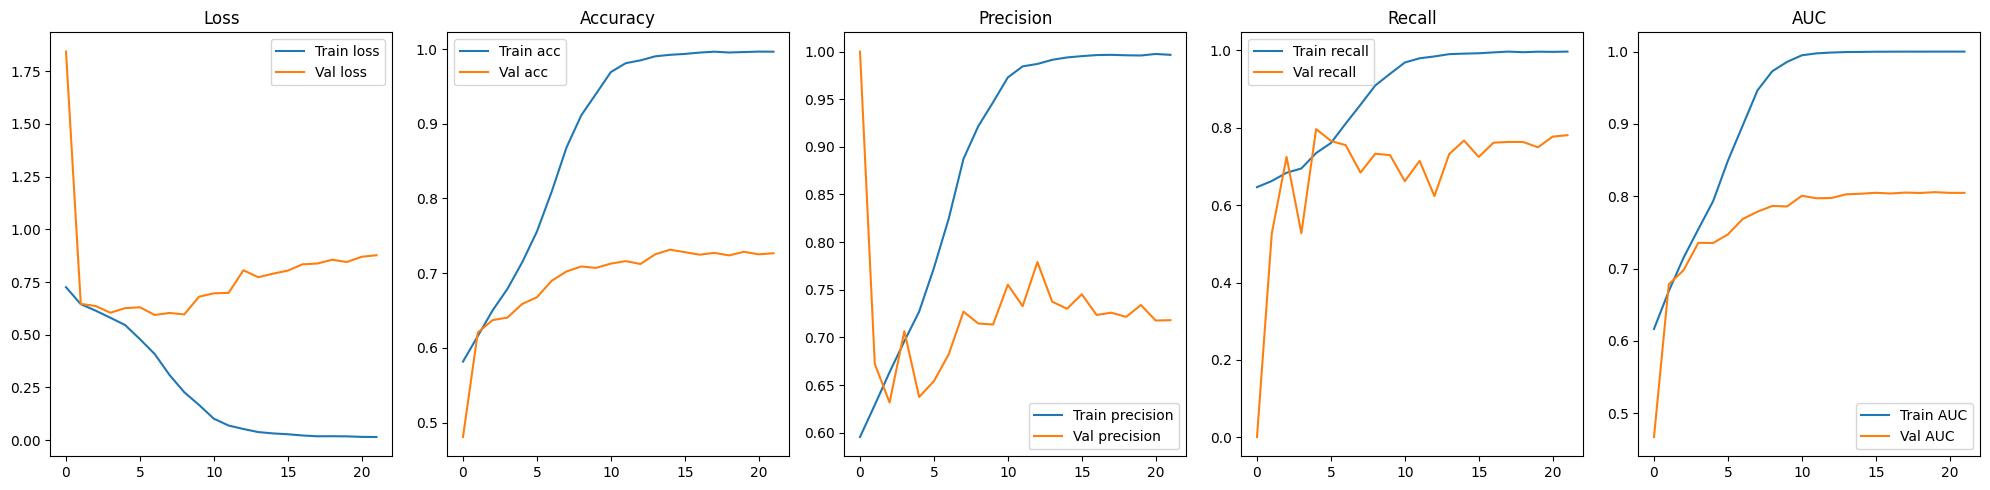

In [72]:
def plot_history(history):
    fig, ax = plt.subplots(1, 5, figsize=(20, 5))

    # ░░ Row 1 : Train & Val Loss ░░
    ax[0].set_title('Loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Val loss")

    # ░░ Row 1 : Train & Val Accuracy ░░
    ax[1].set_title('Accuracy')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Val acc")

    # ░░ Row 1 : Train & Val Precision ░░
    ax[2].set_title('Precision')
    ax[2].plot(history.epoch, history.history["precision"], label="Train precision")
    ax[2].plot(history.epoch, history.history["val_precision"], label="Val precision")

    # ░░ Row 1 : Train & Val Recall ░░
    ax[3].set_title('Recall')
    ax[3].plot(history.epoch, history.history["recall"], label="Train recall")
    ax[3].plot(history.epoch, history.history["val_recall"], label="Val recall")

    # ░░ Row 1 : Train & Val AUC ░░
    ax[4].set_title('AUC')
    ax[4].plot(history.epoch, history.history["auc"], label="Train AUC")
    ax[4].plot(history.epoch, history.history["val_auc"], label="Val AUC")

    for a in ax:
        a.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [73]:
# Loss, Accuracy, Precision, Recall, AUC
baseline.evaluate(val_ds)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6898 - auc: 0.7686 - loss: 0.5937 - precision: 0.6822 - recall: 0.7551


[0.5937393307685852,
 0.6898037195205688,
 0.682196319103241,
 0.7550644278526306,
 0.768589198589325]

# ===================== MODEL BASELINE + DATA AUGMENTATION ======================

In [74]:
def initialize_augmented_model():
    augmented = Sequential([
        layers.Input(shape=(128,128,3)),
        layers.Rescaling(1./255),

        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),

        layers.Conv2D(32, kernel_size = (4,4), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(256, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
        layers.Dropout(0.4),

        layers.Dense(1, activation="sigmoid")
    ])
    return augmented

In [75]:
augmented = initialize_augmented_model()
augmented.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_12 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 128, 128, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,033 (1.62 MB)

 Trainable params: 423,073 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [76]:
def compile_augmented_model(augmented):
    adam = optimizers.Adam(learning_rate = 1e-4)

    augmented.compile(
        loss = "binary_crossentropy",
        optimizer = adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )
    return augmented

In [77]:
%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
augmented = initialize_augmented_model()
augmented = compile_augmented_model(augmented)

ES = EarlyStopping(
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL_2,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=5,
                                        verbose=1,
                                        min_lr=1e-6)
history_2 = augmented.fit(
    train_ds,
    batch_size=32,
    epochs=100,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint,csv_logger_2],
    verbose = 1
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 126ms/step - accuracy: 0.5901 - auc: 0.6193 - loss: 0.6950 - precision: 0.6026 - recall: 0.6556 - val_accuracy: 0.4404 - val_auc: 0.4318 - val_loss: 0.7540 - val_precision: 0.3630 - val_recall: 0.1013 - learning_rate: 1.0000e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 34s 128ms/step - accuracy: 0.6103 - auc: 0.6608 - loss: 0.6554 - precision: 0.6182 - recall: 0.6842 - val_accuracy: 0.5720 - val_auc: 0.5865 - val_loss: 0.6955 - val_precision: 0.5646 - val_recall: 0.7726 - learning_rate: 1.0000e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 34s 130ms/step - accuracy: 0.6304 - auc: 0.6843 - loss: 0.6401 - precision: 0.6379 - recall: 0.6930 - val_accuracy: 0.6166 - val_auc: 0.6929 - val_loss: 0.6401 - val_precision: 0.6004 - val_recall: 0.7845 - learning_rate: 1.0000e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 132ms/step - accuracy: 0.6390 - auc: 0.6898 - loss: 0.6341 - precision: 0.6467 - recall: 0.6967 - val_accuracy: 0.6266 - val_auc: 0.6

# ===================== MODEL BASELINE + DATA AUGMENTATION version 2 ======================

In [78]:
def initialize_augmented_2_model():
    augmented_2 = Sequential([
        layers.Input(shape=(128,128,3)),
        layers.Rescaling(1./255),

        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),

        layers.Conv2D(32, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),
        layers.Dropout(0.2),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),
        layers.Dropout(0.2),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),
        layers.Dropout(0.2),

        layers.Conv2D(256, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),
        layers.Dropout(0.2),

        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(1, activation="sigmoid")
    ])
    return augmented_2

In [79]:
augmented_2 = initialize_augmented_2_model()
augmented_2.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_14 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_4 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 4,586,177 (17.49 MB)

 Trainable params: 4,584,705 (17.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [89]:
def compile_augmented_2_model(augmented_2):
    adam = optimizers.Adam(learning_rate = 1e-3)

    augmented_2.compile(
        loss = "binary_crossentropy",
        optimizer = adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )
    return augmented_2

In [90]:

%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
augmented_2 = initialize_augmented_2_model()
augmented_2 = compile_augmented_model(augmented_2)

ES = EarlyStopping(
    monitor="val_loss",   # explicit is better
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL_3,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=5,
                                        cooldown=2,   # <-- wait 2 epochs after reducing before monitoring again
                                        verbose=1,
                                        min_lr=1e-6)
history_3 = augmented_2.fit(
    train_ds,
    batch_size=32,
    epochs=100,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint,csv_logger_3],
    verbose = 1
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - accuracy: 0.5848 - auc: 0.6150 - loss: 0.7996 - precision: 0.5991 - recall: 0.6450 - val_accuracy: 0.4801 - val_auc: 0.5369 - val_loss: 0.9856 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 132ms/step - accuracy: 0.6035 - auc: 0.6474 - loss: 0.7480 - precision: 0.6179 - recall: 0.6516 - val_accuracy: 0.4998 - val_auc: 0.5827 - val_loss: 0.9264 - val_precision: 0.7808 - val_recall: 0.0525 - learning_rate: 1.0000e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 135ms/step - accuracy: 0.6123 - auc: 0.6597 - loss: 0.7299 - precision: 0.6285 - recall: 0.6491 - val_accuracy: 0.6338 - val_auc: 0.6842 - val_loss: 0.6696 - val_precision: 0.6336 - val_recall: 0.7007 - learning_rate: 1.0000e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 37s 141ms/step - accuracy: 0.6324 - auc: 0.6866 - loss: 0.6948 - precision: 0.6445 - recall: 0.6769 - val_accuracy: 0.6285 - val_

In [82]:
def plot_history(history, history_2, history_3):
    fig, ax = plt.subplots(6, 1, figsize=(12, 24))

    # ░░ Row 1 : Train loss ░░
    ax[0].set_title('Train Loss Comparison')
    ax[0].plot(history.epoch, history.history["loss"], label="Baseline")
    ax[0].plot(history_2.epoch, history_2.history["loss"], label="Augmented", color="red")
    ax[0].plot(history_3.epoch, history_3.history["loss"], label="Augmented_2", color="green")
    ax[0].legend()

    # ░░ Row 2 : Val loss ░░
    ax[1].set_title('Validation Loss Comparison')
    ax[1].plot(history.epoch, history.history["val_loss"], label="Baseline")
    ax[1].plot(history_2.epoch, history_2.history["val_loss"], label="Augmented", color="red")
    ax[0].plot(history_3.epoch, history_3.history["val_loss"], label="Augmented_2", color="green")
    ax[1].legend()

    # ░░ Row 3 : Train Accuracy ░░
    ax[2].set_title('Train Accuracy Comparison')
    ax[2].plot(history.epoch, history.history["accuracy"], label="Baseline")
    ax[2].plot(history_2.epoch, history_2.history["accuracy"], label="Augmented", color="red")
    ax[0].plot(history_3.epoch, history_3.history["accuracy"], label="Augmented_2", color="green")
    ax[2].legend()

    # ░░ Row 4 : Val Accuracy ░░
    ax[3].set_title('Validation Accuracy Comparison')
    ax[3].plot(history.epoch, history.history["val_accuracy"], label="Baseline")
    ax[3].plot(history_2.epoch, history_2.history["val_accuracy"], label="Augmented", color="red")
    ax[0].plot(history_3.epoch, history_3.history["val_accuracy"], label="Augmented_2", color="green")
    ax[3].legend()

    # ░░ Row 5 : Train AUC ░░
    ax[4].set_title('Train AUC Comparison')
    ax[4].plot(history.epoch, history.history["auc"], label="Baseline")
    ax[4].plot(history_2.epoch, history_2.history["auc"], label="Augmented", color="red")
    ax[0].plot(history_3.epoch, history_3.history["auc"], label="Augmented_2", color="green")
    ax[4].legend()

    # ░░ Row 6 : Val AUC ░░
    ax[5].set_title('Validation AUC Comparison')
    ax[5].plot(history.epoch, history.history["val_auc"], label="Baseline")
    ax[5].plot(history_2.epoch, history_2.history["val_auc"], label="Augmented", color="red")
    ax[0].plot(history_3.epoch, history_3.history["val_auc"], label="Augmented_2", color="green")
    ax[5].legend()

    plt.tight_layout()
    plt.show()

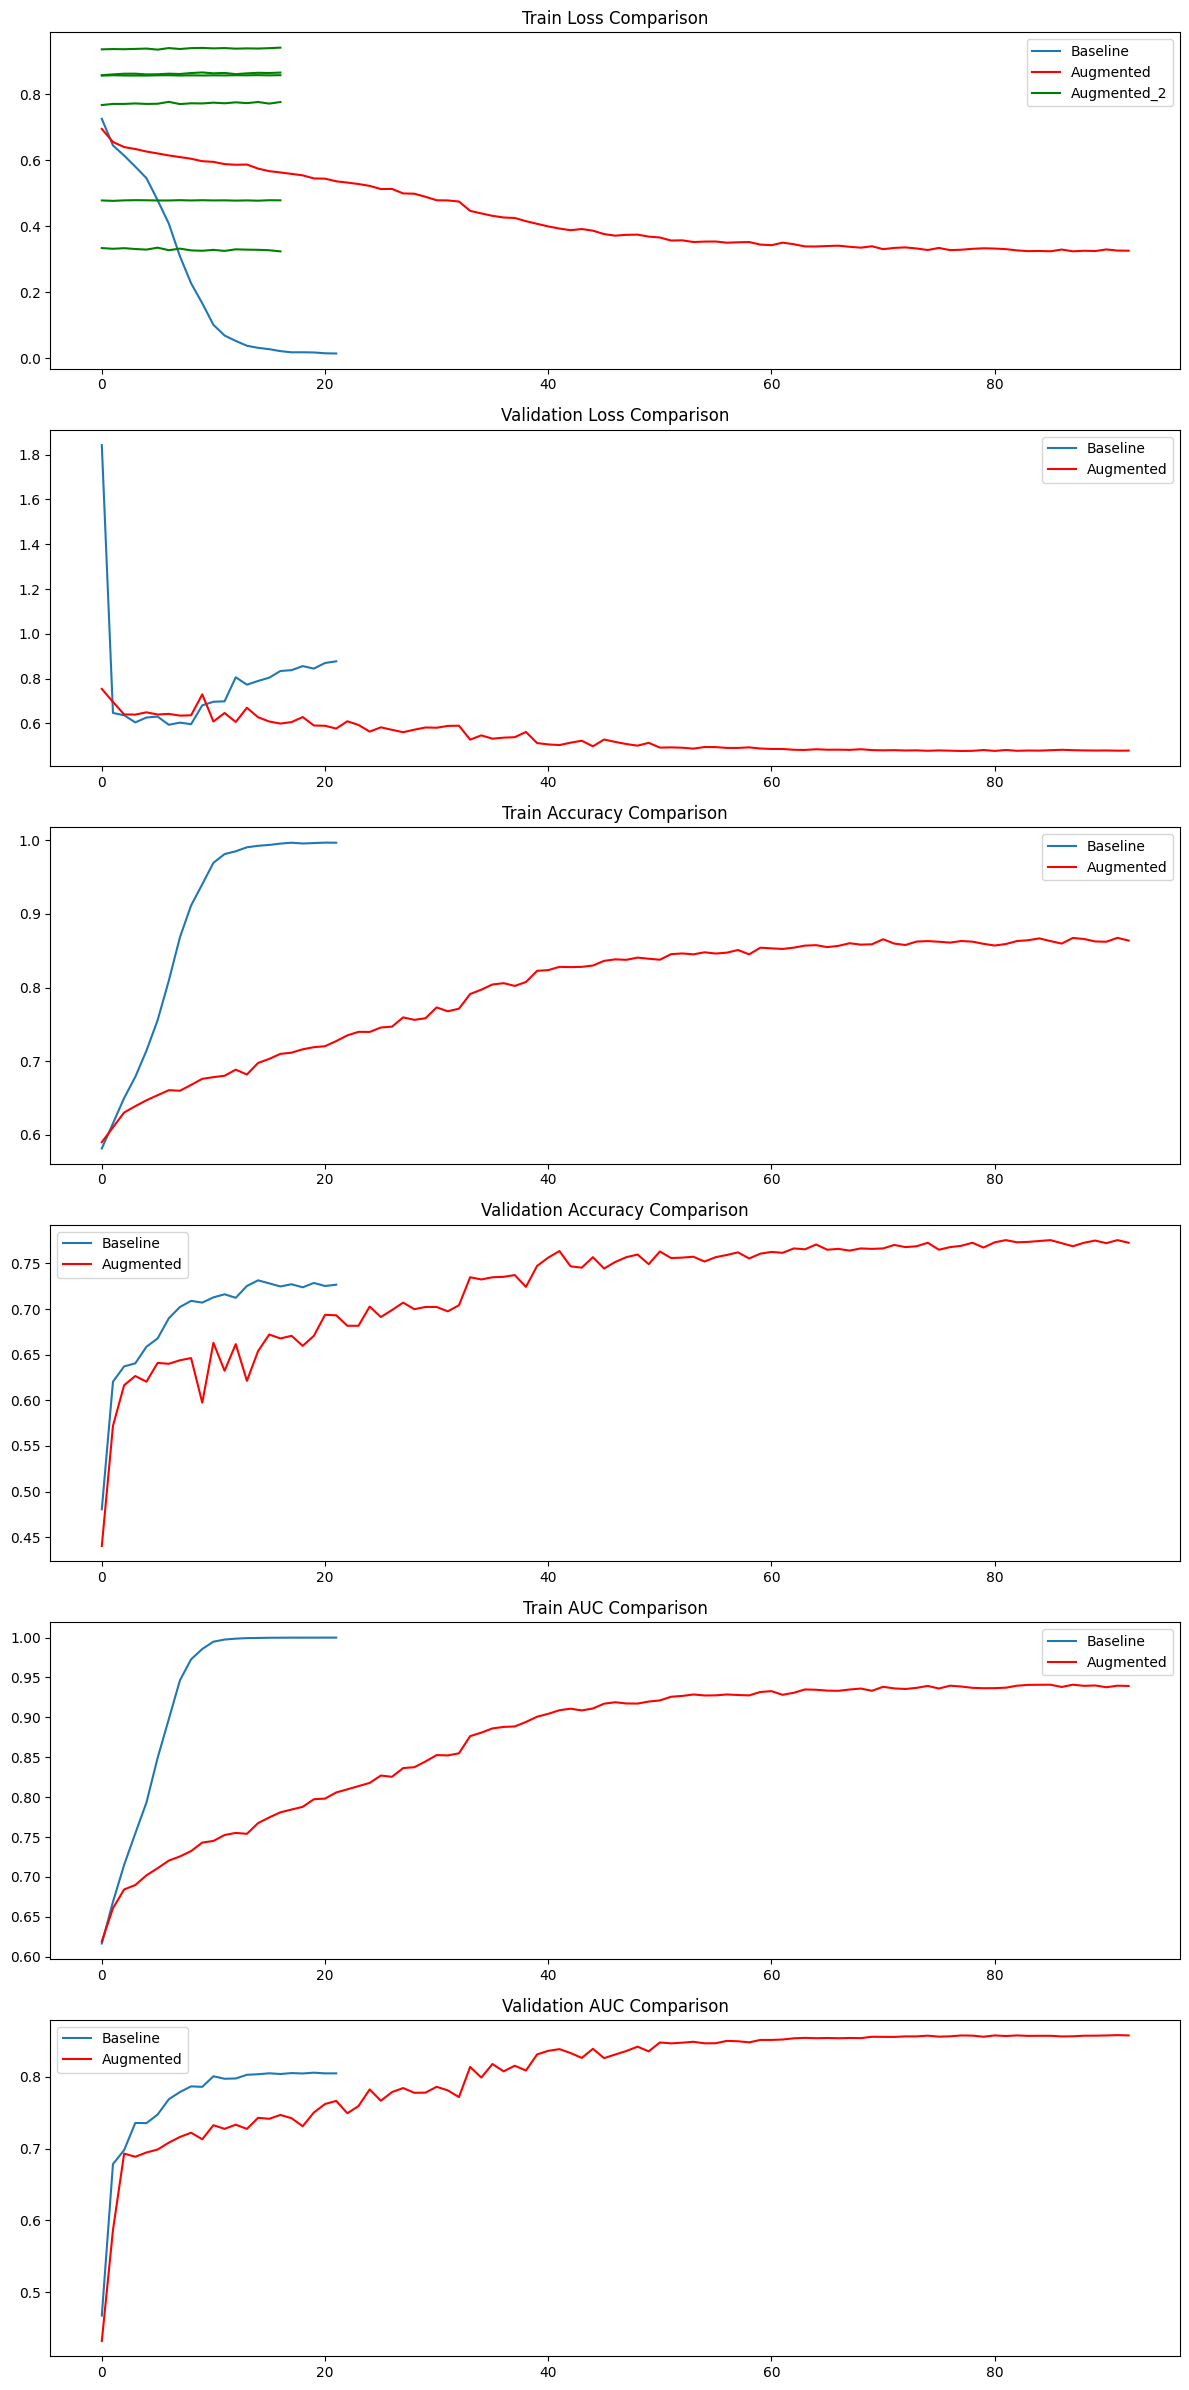

In [83]:
plot_history(history, history_2, history_3)

In [84]:
display(baseline.evaluate(val_ds), augmented.evaluate(val_ds), augmented_2.evaluate(val_ds))

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6898 - auc: 0.7686 - loss: 0.5937 - precision: 0.6822 - recall: 0.7551
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7707 - auc: 0.8574 - loss: 0.4772 - precision: 0.7787 - recall: 0.7808
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4840 - auc: 0.5383 - loss: 0.7239 - precision: 0.7500 - recall: 0.0110


[0.59373939037323,
 0.6898037195205688,
 0.682196319103241,
 0.7550644278526306,
 0.768589198589325]

[0.477206289768219,
 0.7707036733627319,
 0.7786960601806641,
 0.7808471322059631,
 0.8574392199516296]

[0.7238786816596985,
 0.48396360874176025,
 0.75,
 0.01104972418397665,
 0.5383073091506958]

In [85]:
# ░░ 🔮 Prediction ░░

# preds_base = probability that the image belongs to class 1
preds_base = baseline.predict(val_ds, verbose=0)

# preds_aug = probability that the image belongs to class 1
preds_augm = augmented.predict(val_ds, verbose=0)

# preds_aug_2 = probability that the image belongs to class 1
preds_augm_2 = augmented_2.predict(val_ds, verbose=0)

df_prediction = pd.DataFrame({
    "Baseline": preds_base.flatten(),
    "Augmented": preds_augm.flatten(),
    "Augmented_2": preds_augm_2.flatten(),
})

display(df_prediction.head(10))

,Baseline,Augmented,Augmented_2
0,0.539526,0.906104,0.493032
1,0.301043,0.729756,0.486084
2,0.466721,0.926030,0.491098
3,0.946440,0.630810,0.490130
4,0.370834,0.748274,0.489576
5,0.549476,0.047974,0.482122
6,0.888518,0.869688,0.490184
7,0.333250,0.517297,0.489219
8,0.902394,0.348652,0.489676
9,0.366820,0.945953,0.493218


In [86]:
# ░░ 🔮 Prediction Label 1 ░░
# if > 0.5 → 1 else → 0

# Convert baseline predicted probabilities into binary class labels using a 0.5 threshold.
pred_labels = (preds_base > 0.5).astype(int)

# Convert augmented baseline predicted probabilities into binary class labels using a 0.5 threshold.
pred_labels_2 = (preds_augm > 0.5).astype(int)

# Convert augmented baseline 2 predicted probabilities into binary class labels using a 0.5 threshold.
pred_labels_3 = (preds_augm_2 > 0.5).astype(int)

display(pred_labels, pred_labels_2, pred_labels_3)

array([[1],
       [0],
       [0],
       ...,
       [1],
       [1],
       [1]], shape=(2089, 1))

array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [0]], shape=(2089, 1))

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2089, 1))

In [87]:
# ░░ 🎨  Let's have something prettier ░░

df_proba_results = pd.DataFrame({
    "Baseline_proba": preds_base.flatten(),
    "Augmented_proba": preds_augm.flatten(),
    "Augmented_proba_2": preds_augm_2.flatten(),
})

class_map = dict(enumerate(class_names))

df_proba_results["Baseline_label"] = (df_proba_results["Baseline_proba"] > 0.5).astype(int)
df_proba_results["Augmented_label"] = (df_proba_results["Augmented_proba"] > 0.5).astype(int)
df_proba_results["Augmented_2_label"] = (df_proba_results["Augmented_2_proba"] > 0.5).astype(int)
df_proba_results["Baseline_class"] = (df_proba_results["Baseline_label"].map(class_map))
df_proba_results["Augmented_class"] = (df_proba_results["Augmented_label"].map(class_map))
df_proba_results["Augmented_2_class"] = (df_proba_results["Augmented_2_label"].map(class_map))

df_proba_results.to_csv(f"../models/images/baseline/results/baselines_probability_{timestamp}.csv", index=False)

df_proba_results.head(10)

KeyError: 'Augmented_2_proba'

In [37]:
# ░░ 💾 Save all results ░░
os.makedirs("results", exist_ok=True)
results = []

baseline_eval = baseline.evaluate(val_ds, return_dict=True)
augmented_eval = augmented.evaluate(val_ds, return_dict=True)
augmented_2_eval = augmented_2.evaluate(val_ds, return_dict=True)

results.append({
    "model": "🧱 baseline",
    **baseline_eval
})

results.append({
    "model": "💪 augmented",
    **augmented_eval
})

results.append({
    "model": "🦾 augmented_2",
    **augmented_2_eval
})

df_results = pd.DataFrame(results)
df_results.to_csv(f"../models/images/baseline/results/df_results_eval_{timestamp}.csv", index=False)

display(df_results)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6865 - auc: 0.7660 - loss: 0.5895 - precision: 0.7266 - recall: 0.6363
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6506 - auc: 0.7239 - loss: 0.6150 - precision: 0.6266 - recall: 0.8112


,model,accuracy,auc,loss,precision,recall
0,🧱 baseline,0.686453,0.765981,0.589480,0.726604,0.636280
1,💪 augmented,0.650550,0.723937,0.614989,0.626600,0.811234
